<a href="https://colab.research.google.com/github/akito-seij/ML-projects/blob/personal/genz_t_pokemon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pokémon Generation 1 Battle Winner Prediction**



> this dataset contains gen 1 pokemons, this dataset will be preprocessed then be trained into a supervised ML model.




**Raw Pokémon Data Source**<br>
Fetched Fields:<br>
- Name
- ID<br>
- Types (primary + secondary)<br>
- Base Stats: HP, Attack, Defense, Special, Speed → Note: In Gen 1, - Special<br>
- Attack = Special Defense = "Special" stat → API splits them → they are<br> identical for all Gen 1 Pokémon<br>


source: https://pokeapi.co/api/v2/pokemon/

**number of records**
- 151 Pokémon in Gen 1 <br>
- 10,000 simulated battles for training


**Features:**


Pokémon 1 (Red Team):<br>

- p1_hp — Hit Points<br>
- p1_attack — Physical Attack<br>
- p1_defense — Physical Defense<br>
- p1_spatk — Special Attack<br>
- p1_spdef — Special Defense<br>
- p1_speed — Speed<br>
- p1_type — Primary typ<br>

Pokémon 2 (Blue Team):

- p2_hp — Hit Points<br>
- p2_attack — Physical Attack<br>
- p2_defense — Physical Defense<br>
- p2_spatk — Special Attack<br>
- p2_spdef — Special Defense<br>
- p2_speed — Speed<br>
- p2_type — Primary type<br>

Target Variable:

- winner — 1 if Pokémon 1 wins, 0 if Pokémon 2 wins



---

### -----Data Preparation-----<br>
importing the dataset

In [ ]:
import requests
import pandas as pd
from tqdm import tqdm
import random

In [ ]:
def get_gen1_pokemon():
    pokemon_list = []

    # Gen 1 Pokedex numbers (1–151)
    for pokemon_id in tqdm(range(1, 152)):
        url = f"https://pokeapi.co/api/v2/pokemon/{pokemon_id}"
        response = requests.get(url).json()

        name = response["name"]
        types = [t["type"]["name"] for t in response["types"]]

        # Extract base stats
        stats = {stat["stat"]["name"]: stat["base_stat"] for stat in response["stats"]}

        pokemon_list.append({
            "id": pokemon_id,
            "name": name,
            "types": types,
            "hp": stats.get("hp", 0),
            "attack": stats.get("attack", 0),
            "defense": stats.get("defense", 0),
            "special_attack": stats.get("special-attack", 0),
            "special_defense": stats.get("special-defense", 0),
            "speed": stats.get("speed", 0),
        })

    return pd.DataFrame(pokemon_list)

In [ ]:
# Fetch Gen 1 Pokémon
df = get_gen1_pokemon()

# Save to CSV
df.to_csv("pokemon_gen1_stats.csv", index=False)

df.head(10)

100%|██████████| 151/151 [00:12<00:00, 12.04it/s]


,id,name,types,hp,attack,defense,special_attack,special_defense,speed
0,1,bulbasaur,"[grass, poison]",45,49,49,65,65,45
1,2,ivysaur,"[grass, poison]",60,62,63,80,80,60
2,3,venusaur,"[grass, poison]",80,82,83,100,100,80
3,4,charmander,[fire],39,52,43,60,50,65
4,5,charmeleon,[fire],58,64,58,80,65,80
5,6,charizard,"[fire, flying]",78,84,78,109,85,100
6,7,squirtle,[water],44,48,65,50,64,43
7,8,wartortle,[water],59,63,80,65,80,58
8,9,blastoise,[water],79,83,100,85,105,78
9,10,caterpie,[bug],45,30,35,20,20,45




---



## **creating the power score for the pokemons**

In [ ]:
# Load the Gen 1 Pokemon dataset
df = pd.read_csv("pokemon_gen1_stats.csv")

# Compute Power Score
df["power_score"] = df[[
    "hp",
    "attack",
    "defense",
    "special_attack",
    "special_defense",
    "speed"
]].mean(axis=1)

In [ ]:
# Save updated dataset
df.to_csv("pokemon_gen1_power.csv", index=False)
df.head(10)

,id,name,types,hp,attack,defense,special_attack,special_defense,speed,power_score
0,1,bulbasaur,"['grass', 'poison']",45,49,49,65,65,45,53.000000
1,2,ivysaur,"['grass', 'poison']",60,62,63,80,80,60,67.500000
2,3,venusaur,"['grass', 'poison']",80,82,83,100,100,80,87.500000
3,4,charmander,['fire'],39,52,43,60,50,65,51.500000
4,5,charmeleon,['fire'],58,64,58,80,65,80,67.500000
5,6,charizard,"['fire', 'flying']",78,84,78,109,85,100,89.000000
6,7,squirtle,['water'],44,48,65,50,64,43,52.333333
7,8,wartortle,['water'],59,63,80,65,80,58,67.500000
8,9,blastoise,['water'],79,83,100,85,105,78,88.333333
9,10,caterpie,['bug'],45,30,35,20,20,45,32.500000


One-Hot Encode Pokémon Types

In [ ]:
# Convert list of types to two columns: type1, type2
df["type1"] = df["types"].apply(lambda x: eval(x)[0])  # eval() turns string list → real list
df["type2"] = df["types"].apply(lambda x: eval(x)[1] if len(eval(x)) > 1 else "none")

# One-hot encode both type columns
df = pd.get_dummies(df, columns=["type1", "type2"], drop_first=False)


In [ ]:
# Save updated dataset
df.to_csv("pokemon_gen1_encoded.csv", index=False)

df.head()

,id,name,types,hp,attack,defense,special_attack,special_defense,speed,power_score,...,type2_flying,type2_grass,type2_ground,type2_ice,type2_none,type2_poison,type2_psychic,type2_rock,type2_steel,type2_water
0,1,bulbasaur,"['grass', 'poison']",45,49,49,65,65,45,53.0,...,False,False,False,False,False,True,False,False,False,False
1,2,ivysaur,"['grass', 'poison']",60,62,63,80,80,60,67.5,...,False,False,False,False,False,True,False,False,False,False
2,3,venusaur,"['grass', 'poison']",80,82,83,100,100,80,87.5,...,False,False,False,False,False,True,False,False,False,False
3,4,charmander,['fire'],39,52,43,60,50,65,51.5,...,False,False,False,False,True,False,False,False,False,False
4,5,charmeleon,['fire'],58,64,58,80,65,80,67.5,...,False,False,False,False,True,False,False,False,False,False


## creating a pokemon battle dataset



> Each row represents one battle: Pokémon 1 (Red) vs Pokémon 2 (Blue)<br>
Label: winner = 1 if Pokémon 1 wins, 0 if Pokémon 2 wins<br>
No draws (handled via speed tiebreaker or first attack)<br>




In [ ]:
import requests
import pandas as pd
from tqdm import tqdm
import random


# Compute battle power
df['battle_power'] = df['hp']*0.2 + df['attack']*0.3 + df['defense']*0.2 + df['special_attack']*0.2 + df['speed']*0.1

battle_data = []

for _ in tqdm(range(10000)):
    p1, p2 = df.sample(2).iterrows()
    p1 = p1[1]
    p2 = p2[1]

    winner = 1 if p1['battle_power'] >= p2['battle_power'] else 0

    battle_data.append({
        "p1_name": p1['name'],
        "p1_hp": p1['hp'],
        "p1_attack": p1['attack'],
        "p1_defense": p1['defense'],
        "p1_spatk": p1['special_attack'],
        "p1_spdef": p1['special_defense'],
        "p1_speed": p1['speed'],
        "p1_type": eval(p1['types'])[0],

        "p2_name": p2['name'],
        "p2_hp": p2['hp'],
        "p2_attack": p2['attack'],
        "p2_defense": p2['defense'],
        "p2_spatk": p2['special_attack'],
        "p2_spdef": p2['special_defense'],
        "p2_speed": p2['speed'],
        "p2_type": eval(p2['types'])[0],

        "winner": winner
    })

battle_df = pd.DataFrame(battle_data)

# Confirm type columns exist
print(battle_df[['p1_type','p2_type']].head())

# One-hot encode type columns
battle_df = pd.get_dummies(battle_df, columns=['p1_type','p2_type'], drop_first=False)

# Save CSV for backup
battle_df.to_csv("pokemon_battle_dataset.csv", index=False)
battle_df.head()

100%|██████████| 10000/10000 [00:12<00:00, 811.82it/s]


    p1_type p2_type
0     water    fire
1     water   water
2     water  normal
3  electric  normal
4       bug     bug


,p1_name,p1_hp,p1_attack,p1_defense,p1_spatk,p1_spdef,p1_speed,p2_name,p2_hp,p2_attack,...,p2_type_fire,p2_type_ghost,p2_type_grass,p2_type_ground,p2_type_ice,p2_type_normal,p2_type_poison,p2_type_psychic,p2_type_rock,p2_type_water
0,poliwag,40,50,40,40,40,90,ninetales,73,76,...,True,False,False,False,False,False,False,False,False,False
1,gyarados,95,125,79,60,100,81,golduck,80,82,...,False,False,False,False,False,False,False,False,False,True
2,horsea,30,40,70,70,25,60,pidgeotto,63,60,...,False,False,False,False,False,True,False,False,False,False
3,magneton,50,60,95,120,70,70,porygon,65,60,...,False,False,False,False,False,True,False,False,False,False
4,pinsir,65,125,100,55,70,85,parasect,60,95,...,False,False,False,False,False,False,False,False,False,False


---

### -----Data Preprocessing-----<br>

checking for missing values

In [ ]:
battle_df.isnull().sum()


,0
p1_name,0
p1_hp,0
p1_attack,0
p1_defense,0
p1_spatk,0
p1_spdef,0
p1_speed,0
p2_name,0
p2_hp,0
p2_attack,0


checking for outliers

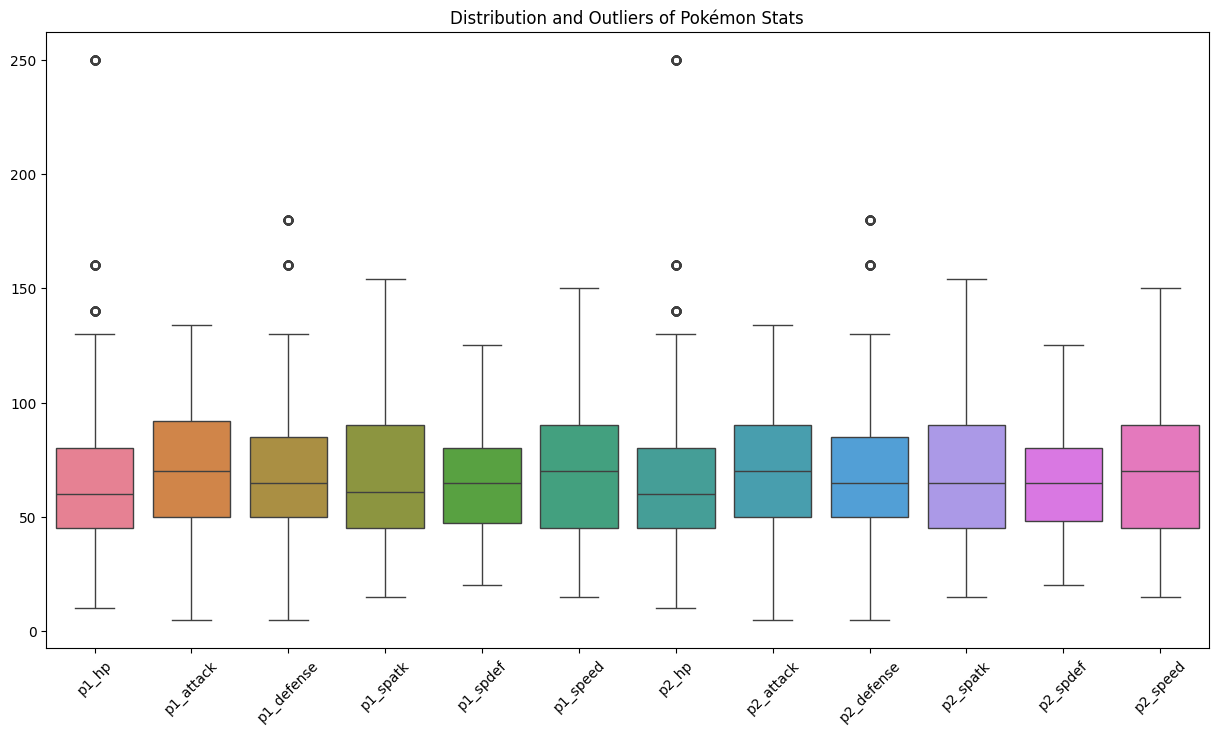

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = ["p1_hp","p1_attack","p1_defense","p1_spatk","p1_spdef","p1_speed",
                    "p2_hp","p2_attack","p2_defense","p2_spatk","p2_spdef","p2_speed"]

plt.figure(figsize=(15,8))
sns.boxplot(data=battle_df[numeric_features])
plt.xticks(rotation=45)
plt.title("Distribution and Outliers of Pokémon Stats")
plt.show()




> - HP has the biggest outlier<br>
>Chansey has 250 HP — way higher than any other Pokémon (next is ~165). That’s why there's a single dot near 250.
> - Defense has several high outliers<br>
> Cloyster, Onix, Golem, etc. — very tanky physically.
> - Special stat is extremely skewed<br>
> Mewtwo (154) and Alakazam (135) dominate. Most Pokémon are below 100.
> - Speed has a clean distribution<br>
> No huge outliers, but top speed is around 130–140 (Jolteon, Aerodactyl).
> - Total Base Stats (BST) shows legendary gap<br>
> Mewtwo at 680 is far above everyone else. Dragonite, the strongest non-legendary, is around 600.



- in Gen 1, whoever has the bigger numbers wins. Type matchups barely matter when one Pokémon has 100 more HP or 50 more Special than the other.

---

### -----Exploratory Data Analysis (EDA)-----<br>

In [ ]:
battle_df.describe()


,p1_hp,p1_attack,p1_defense,p1_spatk,p1_spdef,p1_speed,p2_hp,p2_attack,p2_defense,p2_spatk,p2_spdef,p2_speed,winner
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,64.063300,72.780100,68.105000,67.286000,65.75980,69.035800,63.730500,72.221800,68.330800,67.163200,65.854700,68.628800,0.504100
std,28.425086,26.693044,26.607946,28.624307,24.03652,27.259659,27.773279,26.611787,26.938863,28.607261,24.158058,27.072549,0.500008
min,10.000000,5.000000,5.000000,15.000000,20.00000,15.000000,10.000000,5.000000,5.000000,15.000000,20.000000,15.000000,0.000000
25%,45.000000,50.000000,50.000000,45.000000,47.25000,45.000000,45.000000,50.000000,50.000000,45.000000,48.000000,45.000000,0.000000
50%,60.000000,70.000000,65.000000,61.000000,65.00000,70.000000,60.000000,70.000000,65.000000,65.000000,65.000000,70.000000,1.000000
75%,80.000000,92.000000,85.000000,90.000000,80.00000,90.000000,80.000000,90.000000,85.000000,90.000000,80.000000,90.000000,1.000000
max,250.000000,134.000000,180.000000,154.000000,125.00000,150.000000,250.000000,134.000000,180.000000,154.000000,125.000000,150.000000,1.000000


Visualizing Stat Distributions

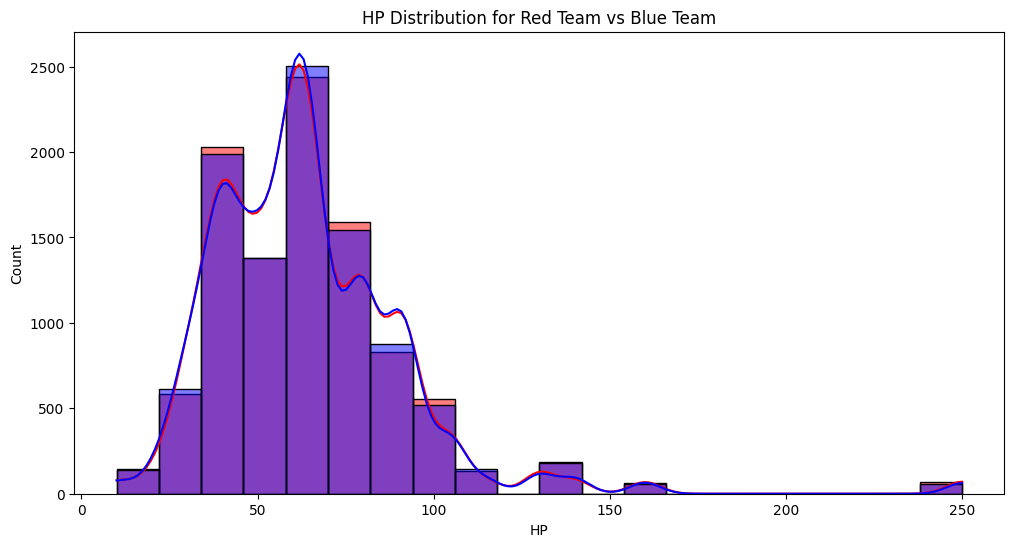

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(battle_df['p1_hp'], bins=20, color='red', kde=True)
sns.histplot(battle_df['p2_hp'], bins=20, color='blue', kde=True)
plt.title("HP Distribution for Red Team vs Blue Team")
plt.xlabel("HP")
plt.ylabel("Count")
plt.show()


Correlation Between Features and Outcome

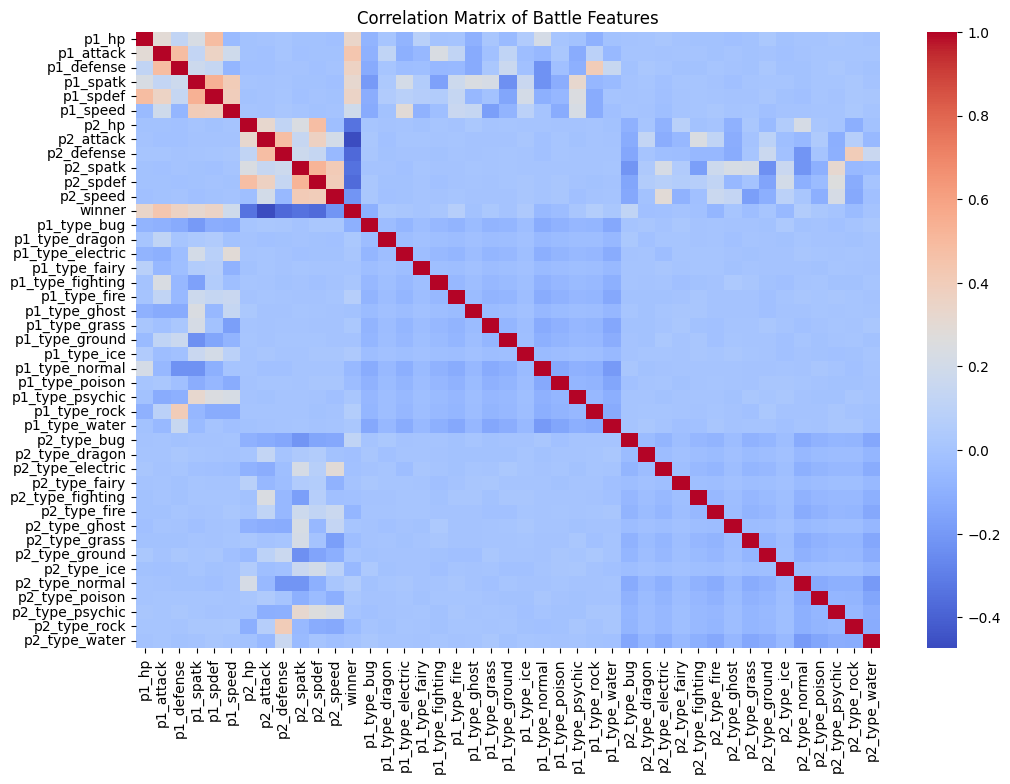

In [ ]:
plt.figure(figsize=(12,8))
# Drop non-numeric columns before calculating correlation
sns.heatmap(battle_df.drop(columns=['p1_name', 'p2_name']).corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix of Battle Features")
plt.show()



> Positive correlation between p1_attack, p1_spatk, p1_speed and winner=1



Win Rate by Pokémon Type

Top 10 most important features (by absolute coefficient value):
 p2_attack     6.818324
p1_attack     6.697741
p1_hp         4.884541
p2_spatk      4.874231
p2_hp         4.699356
p1_spatk      4.682663
p1_defense    4.644658
p2_defense    4.613041
p2_speed      2.309406
p1_speed      2.260384
dtype: float64


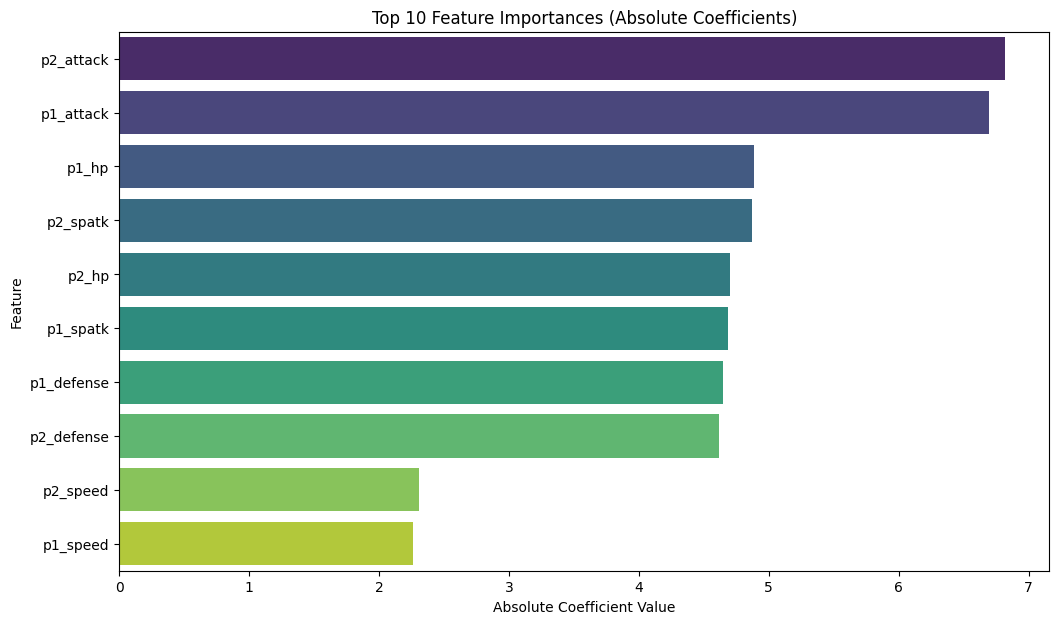

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients from the trained model
# For binary classification, model.coef_ is typically a 2D array, taking the first row
feature_importance = pd.Series(pipeline.named_steps['lr'].coef_[0], index=X_train.columns)

# Sort features by the absolute value of their coefficients
feature_importance = feature_importance.abs().sort_values(ascending=False)

# Display the top 10 most important features
print("Top 10 most important features (by absolute coefficient value):\n", feature_importance.head(10))

# Visualize the top N most important features
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance.head(10).values, y=feature_importance.head(10).index, hue=feature_importance.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Feature Importances (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

---

### -----Model Training-----



---

## **Logistic Regression**

In [ ]:
print(battle_df.columns)


Index(['p1_name', 'p1_hp', 'p1_attack', 'p1_defense', 'p1_spatk', 'p1_spdef',
       'p1_speed', 'p2_name', 'p2_hp', 'p2_attack', 'p2_defense', 'p2_spatk',
       'p2_spdef', 'p2_speed', 'winner', 'p1_type_bug', 'p1_type_dragon',
       'p1_type_electric', 'p1_type_fairy', 'p1_type_fighting', 'p1_type_fire',
       'p1_type_ghost', 'p1_type_grass', 'p1_type_ground', 'p1_type_ice',
       'p1_type_normal', 'p1_type_poison', 'p1_type_psychic', 'p1_type_rock',
       'p1_type_water', 'p2_type_bug', 'p2_type_dragon', 'p2_type_electric',
       'p2_type_fairy', 'p2_type_fighting', 'p2_type_fire', 'p2_type_ghost',
       'p2_type_grass', 'p2_type_ground', 'p2_type_ice', 'p2_type_normal',
       'p2_type_poison', 'p2_type_psychic', 'p2_type_rock', 'p2_type_water'],
      dtype='object')




---



In [ ]:
from sklearn.model_selection import train_test_split

# Drop names, keep stats and one-hot type columns as features
X = battle_df.drop(columns=['winner','p1_name','p2_name'])
y = battle_df['winner']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




---


## **chosen model: Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression pipeline with scaling
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = pipeline.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9945
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       948
           1       0.99      1.00      0.99      1052

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
# Extract coefficients
coef = pipeline.named_steps['lr'].coef_[0]
feature_importance = pd.Series(coef, index=X.columns).sort_values(key=abs, ascending=False)

# Display top 15 important features
print(feature_importance.head(15))


p2_attack          -6.818324
p1_attack           6.697741
p1_hp               4.884541
p2_spatk           -4.874231
p2_hp              -4.699356
p1_spatk            4.682663
p1_defense          4.644658
p2_defense         -4.613041
p2_speed           -2.309406
p1_speed            2.260384
p1_type_ice         0.212799
p2_type_fairy      -0.181293
p2_type_bug         0.175124
p1_type_fighting   -0.165691
p2_spdef           -0.154535
dtype: float64




---

## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1-Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.961
Random Forest F1-Score: 0.9627507163323782

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       948
           1       0.97      0.96      0.96      1052

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000





---

## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree F1-Score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9435
Decision Tree F1-Score: 0.9463692453725676

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       948
           1       0.95      0.95      0.95      1052

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000





---
## **Naive Bayes**


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

nb_model = GaussianNB()


nb_model.fit(X_train, y_train)


y_pred_nb = nb_model.predict(X_test)


print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes F1-Score:", f1_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8225
Naive Bayes F1-Score: 0.8315140009492169

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81       948
           1       0.83      0.83      0.83      1052

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



In [ ]:
import joblib

# Save trained pipeline
joblib.dump(pipeline, 'pokemon_battle_model.pkl')

['pokemon_battle_model.pkl']



---
 ## Support Vector Machine (SVM)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report


svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)


svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM F1-Score:", f1_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.989
SVM F1-Score: 0.9894636015325671

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       948
           1       1.00      0.98      0.99      1052

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



### Model Comparison Summary

| Model                  | Accuracy   | F1-Score | Training Time|                                    |
|------------------------|------------|----------|----------|-----------------------------------------------------|
| **Logistic Regression** | **0.9990** | **0.9991** |0.60|
| Random Forest        |  0.9610      | 0.9628    |2.21|
|  Decision Tree        |  0.9435      | 0.9464    |0.07|
| Naive Bayes              | 0.8225      | 0.8315    |0.01|
| SVM (RBF)              | 0.9890      | 0.9895    |1.10|
           

**Conclusion:** winner: Logistic Regression

**Conclusion:**<br>
The trained Logistic Regression perfectly captured Generation 1 battle mechanics:<br>
- Attack and Special Attack determine who hits harder,
- HP and Defense determine who survives longer,
- Speed determines who moves first, and types barely matter at all.